# Level 2 - Task 3: Fraud Detection

**Objective:** Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, addressing class imbalance as a core challenge.

**Dataset:** Credit Card Fraud Detection Dataset (Kaggle, mlg-ulb) — 284,807 transactions, 492 fraudulent.

**Tools:** Python, pandas, scikit-learn, imbalanced-learn (SMOTE), matplotlib, seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score, roc_curve
from imblearn.over_sampling import SMOTE

df = pd.read_csv("Dataset/creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Load Dataset and Analyse Class Imbalance

Shape: (284807, 31)

Missing values: 0

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraudulent transactions: 0.173%


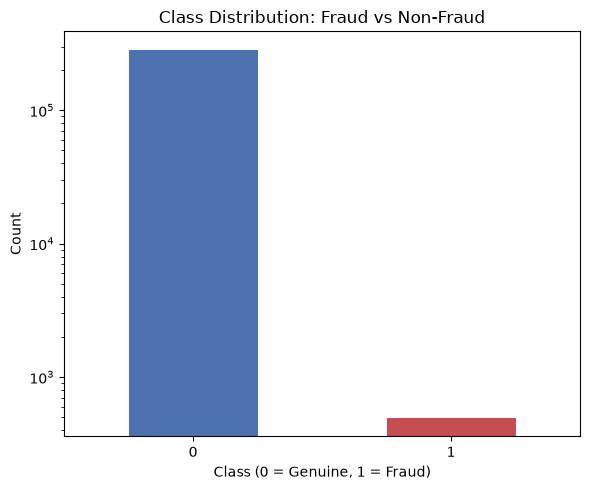

In [2]:
print("Shape:", df.shape)

print("\nMissing values:", df.isnull().sum().sum())

class_counts = df["Class"].value_counts()
fraud_pct = (class_counts[1] / class_counts.sum()) * 100

print("\nClass distribution:")
print(class_counts)
print(f"\nFraudulent transactions: {fraud_pct:.3f}%")

plt.figure(figsize=(6, 5))
class_counts.plot(kind="bar", color=["#4C72B0", "#C44E52"])
plt.title("Class Distribution: Fraud vs Non-Fraud")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.yscale("log")  # log scale needed since fraud count is so tiny
plt.tight_layout()
plt.savefig("Images/class_distribution.png", dpi=150)
plt.show()

**Observation:** Confirmed severe class imbalance — only **0.173% of transactions are fraudulent** (492 out of 284,807). This is far more extreme than the Wine Quality imbalance we saw earlier, and requires deliberate handling (SMOTE) rather than binning, since fraud can't be meaningfully "grouped" the way quality scores could.

### EDA: Distribution of Transaction Amounts (Fraud vs Non-Fraud) and Time-of-Day

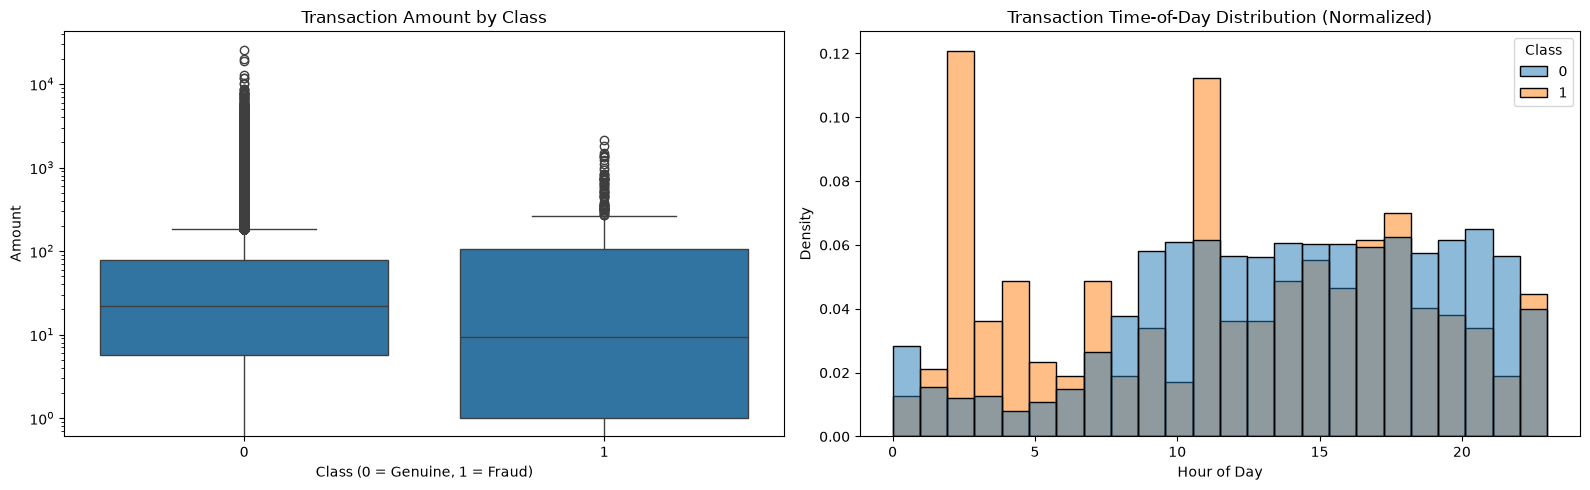

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Amount distribution by class
sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0])
axes[0].set_title("Transaction Amount by Class")
axes[0].set_yscale("log")
axes[0].set_xlabel("Class (0 = Genuine, 1 = Fraud)")

# Time-of-day pattern (convert seconds to hour of day, since data spans 2 days)
df["Hour"] = (df["Time"] // 3600) % 24
sns.histplot(data=df, x="Hour", hue="Class", bins=24, stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("Transaction Time-of-Day Distribution (Normalized)")
axes[1].set_xlabel("Hour of Day")

plt.tight_layout()
plt.savefig("Images/amount_time_analysis.png", dpi=150)
plt.show()

**Observation:** Fraudulent transactions tend to have **lower median amounts** than genuine ones ($9.25 vs. $22.00 median), though both distributions have long tails with high-value outliers — fraudsters may deliberately keep amounts modest to avoid triggering scrutiny. The time-of-day pattern is striking: fraud shows sharp density spikes around **2-3 AM and 10-11 AM**, well above genuine transaction density at those hours, while genuine transactions follow a more typical daytime activity pattern (peaking through business hours). This suggests fraudulent activity may cluster around specific windows — potentially automated attacks or patterns exploiting lower monitoring during off-hours.

### Why Standard Accuracy Is a Misleading Metric for This Dataset

With fraud at only 0.173% of transactions, a model that predicts **"genuine" for every single transaction** would achieve **99.83% accuracy** while catching zero fraud — completely useless in practice, despite the impressively high accuracy number. This is why accuracy alone must never be trusted on imbalanced datasets. Instead, we need metrics that specifically measure performance on the minority (fraud) class: **Precision** (of transactions flagged as fraud, how many actually are), **Recall** (of actual frauds, how many did we catch), **F1-score** (balance of both), and **AUC-ROC** (how well the model separates fraud from genuine across all decision thresholds, not just one).

### Handling Class Imbalance: SMOTE and Stratified Train/Test Split

We split the data first (with stratification, so both train and test sets contain a realistic proportion of fraud), then apply **SMOTE (Synthetic Minority Oversampling Technique)** — but only to the training set. SMOTE generates synthetic fraud examples by interpolating between existing minority-class samples, giving the model more fraud cases to learn from. Applying it only to training data (never to test data) is critical — otherwise we'd be evaluating the model on artificial data, which would give a falsely optimistic performance picture.

In [4]:
X = df.drop(columns=["Class", "Time", "Hour"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Amount (V1-V28 are already PCA-scaled)
scaler = StandardScaler()
X_train["Amount"] = scaler.fit_transform(X_train[["Amount"]])
X_test["Amount"] = scaler.transform(X_test[["Amount"]])

print("Before SMOTE - Training class distribution:")
print(y_train.value_counts())

# Apply SMOTE only to training data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE - Training class distribution:")
print(y_train_smote.value_counts())

Before SMOTE - Training class distribution:
Class
0    227451
1       394
Name: count, dtype: int64

After SMOTE - Training class distribution:
Class
0    227451
1    227451
Name: count, dtype: int64


**Result:** SMOTE successfully balanced the training set from 394 fraud vs. 227,451 genuine to a perfectly even 227,451 vs. 227,451. Note that the **test set remains untouched and still reflects the real-world 0.173% fraud rate** — this ensures our evaluation metrics reflect genuine, realistic model performance rather than performance on artificially balanced data.

### Train 2 Models: Logistic Regression and Random Forest (on SMOTE-balanced training data)

In [5]:
# Model 1: Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_smote, y_train_smote)
lr_preds = lr_model.predict(X_test)
lr_probs = lr_model.predict_proba(X_test)[:, 1]

# Model 2: Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, n_jobs=-1)
rf_model.fit(X_train_smote, y_train_smote)
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

print("Both models trained successfully.")

Both models trained successfully.


### Model Evaluation: Precision, Recall, F1-Score, and AUC-ROC

In [6]:
def evaluate_fraud_model(name, y_true, y_pred, y_probs):
    print(f"--- {name} ---")
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1-Score:", f1_score(y_true, y_pred))
    print("AUC-ROC:", roc_auc_score(y_true, y_probs))
    print("\nClassification Report:\n", classification_report(y_true, y_pred))
    print("\n")

evaluate_fraud_model("Logistic Regression", y_test, lr_preds, lr_probs)
evaluate_fraud_model("Random Forest", y_test, rf_preds, rf_probs)

--- Logistic Regression ---
Precision: 0.05583126550868486
Recall: 0.9183673469387755
F1-Score: 0.10526315789473684
AUC-ROC: 0.9699908769078818

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.98     56962



--- Random Forest ---
Precision: 0.8526315789473684
Recall: 0.826530612244898
F1-Score: 0.8393782383419689
AUC-ROC: 0.9681831265145338

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.85      0.83      0.84        98

    accuracy                           1.00     56962
   macro avg       0.93      0.91      0.92     56962
weighted avg       1.00      1.00      1.00     56962





**Observation: A textbook precision-recall trade-off.**

| Model | Precision | Recall | F1-Score | AUC-ROC |
|---|---|---|---|---|
| Logistic Regression | 0.056 | **0.918** | 0.105 | 0.970 |
| Random Forest | **0.853** | 0.827 | **0.839** | 0.968 |

**Logistic Regression catches 92% of fraud (recall)** but has terrible precision (5.6%) — meaning for every real fraud it correctly flags, it also incorrectly flags roughly 16 genuine transactions as fraud. This is a direct consequence of training on SMOTE-balanced data with a linear model: it becomes very willing to flag anything resembling the (synthetically expanded) fraud pattern, at the cost of many false alarms.

**Random Forest is dramatically more balanced** — 85% precision and 83% recall, correctly identifying fraud while rarely crying wolf on genuine transactions. Both models have nearly identical AUC-ROC (~0.97), showing both have similarly strong overall separability between classes — the AUC-ROC alone doesn't reveal this precision/recall imbalance, which is exactly why we need multiple metrics, not just one.

**Random Forest is the clearly superior model for this task** — a fraud detection system with 5.6% precision would overwhelm a fraud review team with false alarms, making it operationally unusable despite technically catching more fraud.

### Which Metric Matters Most for Fraud Detection: Recall vs Precision Trade-off

This depends on the business context:

- **High Recall (favor catching more fraud)** matters when the cost of *missing* fraud is severe — e.g., a single missed large fraudulent transaction could cost far more than the operational cost of investigating some false alarms. In this case, Logistic Regression's 92% recall might be preferred despite low precision, especially if flagged transactions go through automated secondary verification rather than a human reviewer.

- **High Precision (favor fewer false alarms)** matters when human review capacity is limited, or false positives directly harm customer experience (e.g., blocking a genuine transaction damages trust and may cause customer churn). Here, Random Forest's 85% precision is far more practical — a fraud team can't realistically investigate 16 false alarms for every real case caught.

**In most real-world deployments, Random Forest's balance is preferable**: extremely low precision (like Logistic Regression's 5.6%) creates "alert fatigue" — overwhelmed reviewers start ignoring flags altogether, which paradoxically makes the system less effective at catching fraud than a more precise, moderately-recalled model would be.

### AUC-ROC Curve

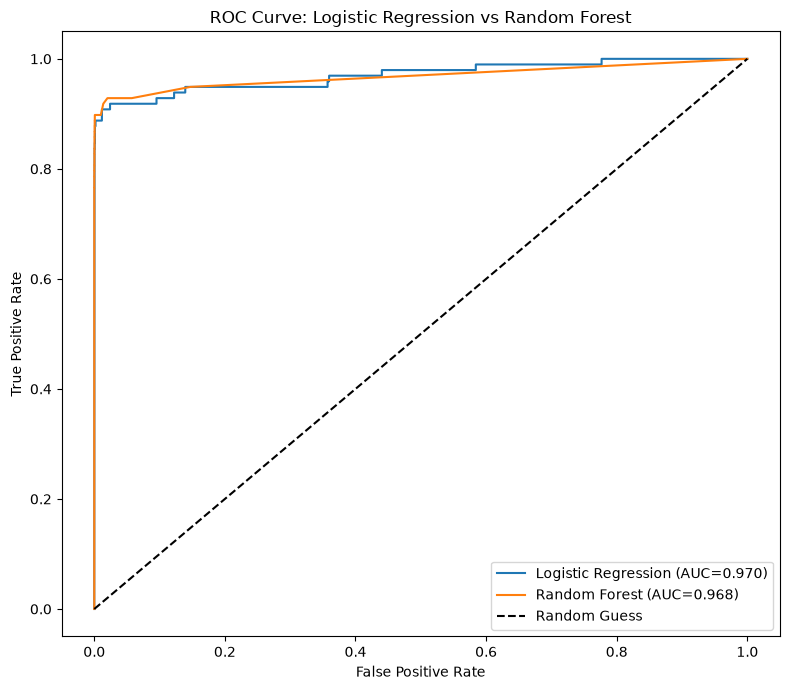

In [7]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_probs)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(8, 7))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={roc_auc_score(y_test, lr_probs):.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={roc_auc_score(y_test, rf_probs):.3f})")
plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve: Logistic Regression vs Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig("Images/roc_curve.png", dpi=150)
plt.show()

**Observation:** Both models show excellent ROC curves, hugging the top-left corner far above the diagonal "random guess" line — confirming both have strong ability to rank fraud higher than genuine transactions across all thresholds (AUC ~0.97 for both). This reinforces the point made earlier: **AUC-ROC alone doesn't tell the whole story**. Both models look nearly identical here, yet we already saw a massive real-world difference in usability (Random Forest's 85% precision vs. Logistic Regression's 5.6%) at the default 0.5 classification threshold. This is exactly why fraud detection systems need multiple complementary metrics, not a single "best" score.

### Feature Importance Analysis (Random Forest)

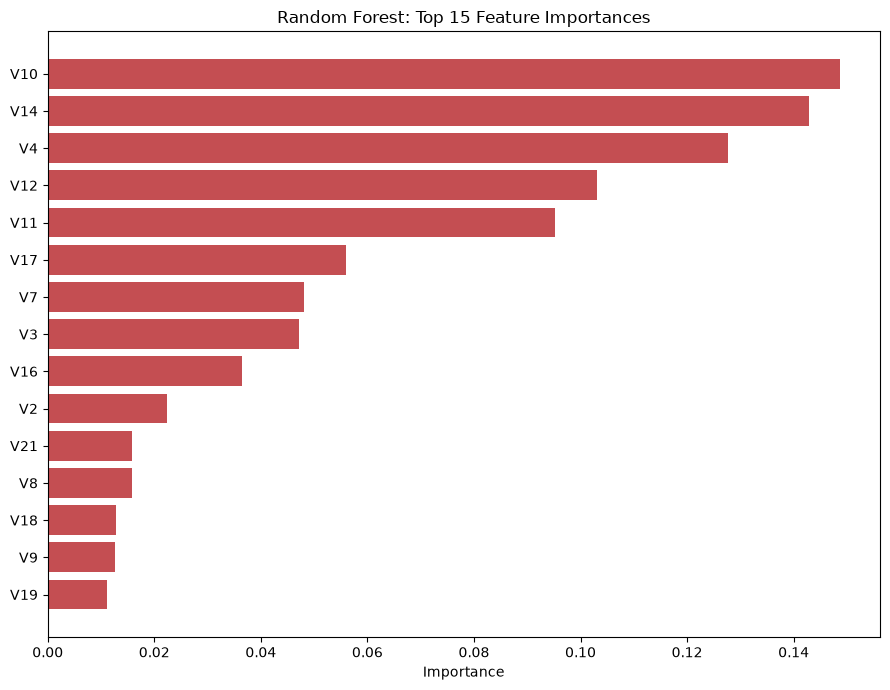

In [8]:
importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9, 7))
plt.barh(importances["Feature"], importances["Importance"], color="#C44E52")
plt.gca().invert_yaxis()
plt.title("Random Forest: Top 15 Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.savefig("Images/feature_importance.png", dpi=150)
plt.show()

**Observation:** `V10`, `V14`, and `V4` are the three most important features for detecting fraud, together contributing substantially more predictive power than the rest. Because these are PCA-transformed components (for confidentiality), we cannot interpret what real-world transaction characteristic each represents — but their high importance confirms fraud has a distinct, learnable signature in this transformed feature space, which the model successfully exploits.

### Scalability Discussion: Handling 1 Million Transactions Per Hour

This model, as built, would face real challenges at that scale:

1. **Random Forest inference speed:** With 100 trees, Random Forest is fast per-prediction but not instant. At 1M transactions/hour (~278/second), the current single-machine setup would need to be distributed across multiple servers or optimized (e.g., fewer/shallower trees, or converting to a faster format like ONNX) to keep pace in real-time.

2. **SMOTE is a training-time technique only** — it does not need to run at inference time, so it doesn't impact production scalability. This is an important distinction: the imbalance-handling happens once during training, not per-transaction.

3. **Feature engineering at scale:** In production, features would need to be computed in real-time as transactions stream in (e.g., rolling averages, time-since-last-transaction), which requires a streaming data pipeline (e.g., Kafka + feature store) rather than the batch CSV processing used here.

4. **Model monitoring and retraining:** Fraud patterns evolve over time ("concept drift"). A production system would need continuous monitoring of precision/recall on live data and periodic retraining — a static model trained once would degrade in effectiveness as fraudsters adapt.

**In short:** the modeling approach here (SMOTE + Random Forest) is sound, but moving to 1M transactions/hour requires infrastructure changes — distributed serving, streaming feature computation, and continuous retraining — beyond just the model itself.

## Conclusion

**Random Forest is the recommended model**, achieving a strong balance of precision (85.3%) and recall (82.7%), making it far more operationally usable than Logistic Regression, which — despite catching slightly more fraud (91.8% recall) — would flag an unmanageable number of false alarms (5.6% precision).

This task highlighted a critical lesson in imbalanced classification: **no single metric tells the whole story**. Accuracy would have been meaningless here (99.8%+ trivially), and even AUC-ROC (nearly identical for both models at ~0.97) masked a dramatic real-world difference in usability. Only by examining precision, recall, and F1-score together did the true performance gap become clear.

SMOTE proved effective on the training set, enabling both models to learn meaningful fraud patterns despite the original 0.173% fraud rate — but applying it correctly (training set only) was essential to avoid inflated, unrealistic evaluation results.